# GPU Hello World

### Task 3

1. Make a NumPy matrix
2. Install, import and initialize PyCUDA
3. Make a GPU matrix
4. Copy the NumPy matrix data to the GPU
5. Write a GPU *kernel* that does some kind of computation on an input matrix
6. Copy the result back to the CPU
7. Print and plot both matrices

### Solution 3

<-- see `hello_world_pycuda_solution.ipynb`

In [15]:
import numpy as np
import matplotlib.pyplot as plt

import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule

# Info about the GPU
device = cuda.Device(0)

print("GPU usada:", device.name())
print("Compute Capability:", device.compute_capability())
print("Memoria total (MB):", device.total_memory() // (1024**2))

attrs = device.get_attributes()

print("Multiprocessors:", attrs[cuda.device_attribute.MULTIPROCESSOR_COUNT])
print("Max threads per block:",
      attrs[cuda.device_attribute.MAX_THREADS_PER_BLOCK])



GPU usada: NVIDIA GeForce RTX 2070
Compute Capability: (7, 5)
Memoria total (MB): 8191
Multiprocessors: 36
Max threads per block: 1024


In [16]:
# 1. Make a NumPy matrix and allocate memory on the GPU
A = np.random.rand(4, 4).astype(np.float32)

# Create an empty matrix for the results in CPU memory
B = np.empty_like(A)


In [17]:
# 3-4. Make GPU matrices and copy NumPy data to GPU
A_gpu = cuda.mem_alloc(A.nbytes)
B_gpu = cuda.mem_alloc(B.nbytes)

cuda.memcpy_htod(A_gpu, A)

In [18]:
# 5. Write GPU kernel
kernel_code = """
__global__ void matrix_square(float *A, float *B, int rows, int cols)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < rows && col < cols)
    {
        int idx = row * cols + col;
        B[idx] = A[idx] * A[idx];
    }
}
"""

mod = SourceModule(kernel_code)
matrix_square = mod.get_function("matrix_square")

rows, cols = A.shape

block_size = (16, 16, 1)
grid_size = (
    int(np.ceil(cols / block_size[0])),
    int(np.ceil(rows / block_size[1])),
    1
)

matrix_square(
    A_gpu,
    B_gpu,
    np.int32(rows),
    np.int32(cols),
    block=block_size,
    grid=grid_size
)



In [19]:
# 6. Copy result back to CPU
cuda.memcpy_dtoh(B, B_gpu)

Original matrix A:
[[1.4421901e-01 4.8970512e-01 7.0657873e-01 5.4429809e-04]
 [1.9116314e-01 3.1442213e-01 2.9641026e-01 7.9394750e-02]
 [8.9672750e-01 2.8101233e-01 3.1286421e-01 9.8227853e-01]
 [6.6199899e-01 2.3961534e-01 2.8023982e-01 9.7096473e-01]]

Result matrix B = A^2:
[[2.0799123e-02 2.3981111e-01 4.9925351e-01 2.9626042e-07]
 [3.6543347e-02 9.8861277e-02 8.7859042e-02 6.3035265e-03]
 [8.0412024e-01 7.8967929e-02 9.7884014e-02 9.6487111e-01]
 [4.3824267e-01 5.7415508e-02 7.8534357e-02 9.4277251e-01]]


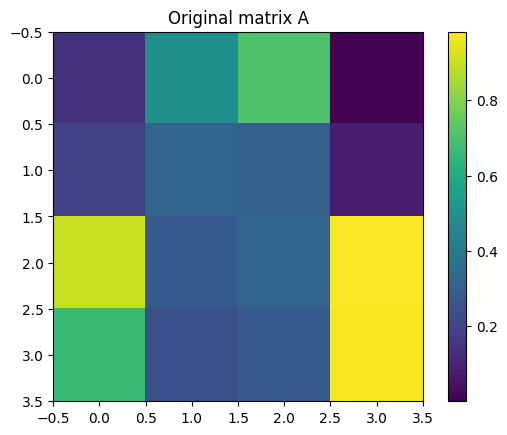

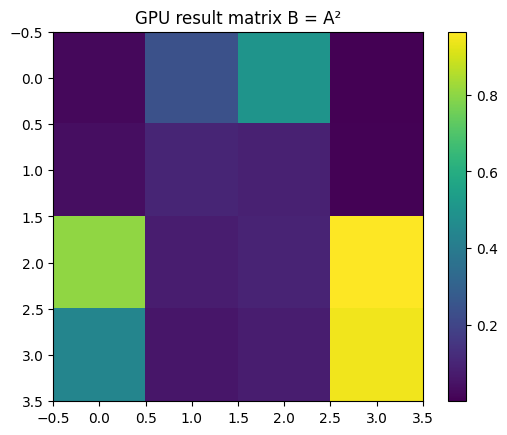

In [20]:
# 7. Print and plot both matrices
print("Original matrix A:")
print(A)

print("\nResult matrix B = A^2:")
print(B)

plt.figure()
plt.imshow(A)
plt.title("Original matrix A")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(B)
plt.title("GPU result matrix B = A²")
plt.colorbar()
plt.show()